## Swin Transformer V1 Tiny Training

Treino e avaliação de um modelo Swin Transformer V1 Tiny utilizando imagens reais e geradas pelo VAE para a classificação das patologias do dataset de CPRE, incluindo análise final via Grad-CAM.

## Imports necessários

In [ ]:
from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot

%matplotlib inline
import matplotlib.pyplot as plt

from monai.transforms import (
    Activations, AsDiscrete, LoadImage, EnsureChannelFirst, Resize,
    RandZoom, RandAdjustContrast, RandGaussianNoise, RandRotate,
    ToTensor, Compose, NormalizeIntensity, Lambda
)
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.utils import set_determinism
from monai.config import print_config

import numpy as np
import os
from PIL import Image
import random
import seaborn as sns
import time

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

import torch
from torch.utils.data import Dataset
import torch.nn as nn
from torchmetrics.classification import MulticlassF1Score

import timm


print_config()

model_name = "./models/swin_tiny_v1.pth"

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

MONAI version: 1.5.2
Numpy version: 2.2.6
Pytorch version: 2.6.0+cu124
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: c:\Users\<username>\miniconda3\envs\Aulas_DAA\Lib\site-packages\monai\__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: NOT INSTALLED or UNKNOWN VERSION.
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: 1.16.1
Pillow version: 12.1.0
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: 6.0.0
TorchVision version: 0.21.0+cu124
tqdm version: 4.67.1
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.0.0
pandas version: 2.3.3
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: 5.3.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT

## Preparar dataset

In [2]:
base_dir = "./dataset_monica"
phases = ["train", "val", "test"]

data = {phase: {"images": [], "labels": []} for phase in phases}

class_names = sorted([
    x for x in os.listdir(os.path.join(base_dir, "train"))
    if os.path.isdir(os.path.join(base_dir, "train", x))
])

num_class = len(class_names)
print("Classes:", class_names)
print("Num classes:", num_class)

valid_exts = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        image_files = [
            os.path.join(class_dir, x)
            for x in os.listdir(class_dir)
            if x.lower().endswith(valid_exts)
        ]
        data[phase]["images"].extend(image_files)
        data[phase]["labels"].extend([i] * len(image_files))

for phase in phases:
    load_images_labels(phase)

for phase in phases:
    print(f"{phase.upper()} real count = {len(data[phase]['images'])}")

Classes: ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
Num classes: 4
TRAIN real count = 1067
VAL real count = 234
TEST real count = 267


## Adicionar imagens sintéticas

In [3]:
VAE_GEN_BASE = "./vae_generated_perceptual"

vae_classes = {
    "Biliary_Leaks": 300,
    "Normal": 213,
    "Stricture": 155
}

print("\n--- Adding synthetic images ONLY to TRAIN ---")

for class_name, n_max in vae_classes.items():
    class_idx = class_names.index(class_name)
    gen_dir = os.path.join(VAE_GEN_BASE, class_name)

    gen_files = sorted([
        os.path.join(gen_dir, f)
        for f in os.listdir(gen_dir)
        if f.lower().endswith(".png")
    ])[:n_max]

    data["train"]["images"].extend(gen_files)
    data["train"]["labels"].extend([class_idx] * len(gen_files))

    print(f"VAE {class_name}: {len(gen_files)} added")

print("\nFINAL COUNTS:")
for phase in phases:
    print(f"{phase.upper()} total = {len(data[phase]['images'])}")


--- Adding synthetic images ONLY to TRAIN ---
VAE Biliary_Leaks: 300 added
VAE Normal: 213 added
VAE Stricture: 155 added

FINAL COUNTS:
TRAIN total = 1735
VAL total = 234
TEST total = 267


## Distribuição das classes

----- TRAIN CASES -----
cases: 1735


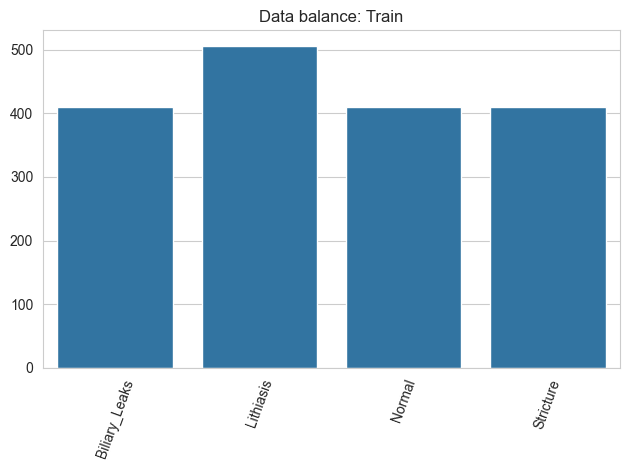

----- VALIDATION CASES -----
cases: 234


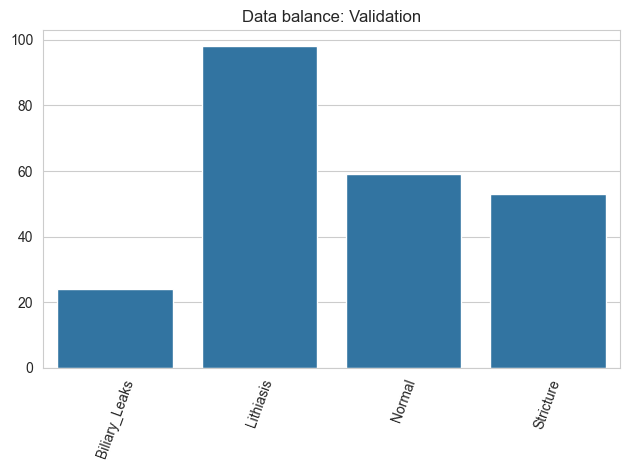

----- TEST CASES -----
cases: 267


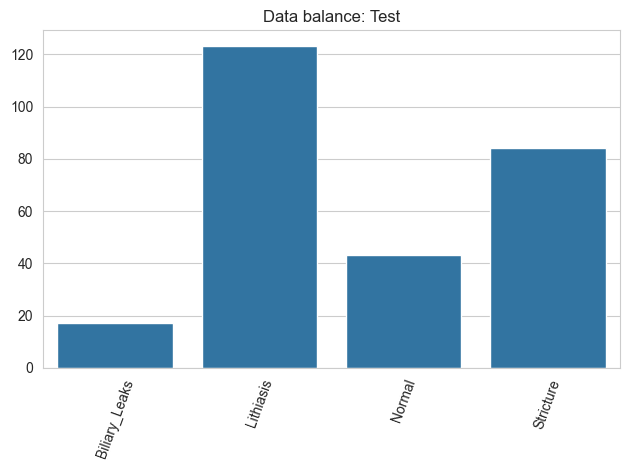

In [4]:
def visualize_holdout_balance(labels, class_names, header):
    sns.set_style("whitegrid")
    print("cases:", len(labels))
    x, y = np.unique(labels, return_counts=True)
    x_ext = [class_names[n] for n in x]
    grafico = sns.barplot(x=x_ext, y=y)
    grafico.set_title(f"Data balance: {header}")
    plt.xticks(rotation=70)
    plt.tight_layout()
    plt.show()

print("----- TRAIN CASES -----")
visualize_holdout_balance(data["train"]["labels"], class_names, "Train")

print("----- VALIDATION CASES -----")
visualize_holdout_balance(data["val"]["labels"], class_names, "Validation")

print("----- TEST CASES -----")
visualize_holdout_balance(data["test"]["labels"], class_names, "Test")

## Transforms
Define data augmentation and preprocessing for training and validation. Images are resized to 224×224.

In [5]:
def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img

from monai.transforms import ScaleIntensity, NormalizeIntensity

train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((224, 224)),
    RandRotate(range_x=np.pi/12, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    RandAdjustContrast(prob=0.5),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.01),
    ScaleIntensity(),
    Lambda(repeat_if_needed),
    NormalizeIntensity(nonzero=True, channel_wise=True),
    ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((224, 224)),
    ScaleIntensity(),
    Lambda(repeat_if_needed),
    NormalizeIntensity(nonzero=True, channel_wise=True),
    ToTensor()
])

act = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)

## Dataset e DataLoaders

In [ ]:
# class do dataset
class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        image = self.image_files[index]
        return self.transforms(image), self.labels[index]

# Dataloaders
train_ds = MedNISTDataset(data["train"]["images"], data["train"]["labels"], train_transforms)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0)

val_ds = MedNISTDataset(data["val"]["images"], data["val"]["labels"], val_transforms)
val_loader = DataLoader(val_ds, batch_size=4, num_workers=0)

test_ds = MedNISTDataset(data["test"]["images"], data["test"]["labels"], val_transforms)
test_loader = DataLoader(test_ds, batch_size=4, num_workers=0)

print("Train:", len(train_ds))
print("Val:", len(val_ds))
print("Test:", len(test_ds))

Train: 1735
Val: 234
Test: 267


## Modelo


In [7]:
model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=num_class
)

model = model.to(device)
print(model)

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

## Função treino

In [ ]:
def train_model(train_dl, val_dl, model, loss_function, optimizer, epochs, name):
    early_stopping_patience = 10
    epochs_without_improvement = 0
    liveloss = PlotLosses(outputs=[MatplotlibPlot(figpath=f"{name}.png")])
    best_metric = -1
    best_metric_epoch = -1

    f1_metric = MulticlassF1Score(num_classes=num_class, average="macro").to(device)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    for epoch in range(epochs):
        logs = {}

        # treino
        model.train()
        running_loss = 0.0
        running_corrects = 0.0

        y_pred_train = torch.tensor([], dtype=torch.float32, device=device)
        y_train = torch.tensor([], dtype=torch.long, device=device)

        for inputs, labels in train_dl:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = loss_function(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.detach() * inputs.size(0)
            _, preds = torch.max(outputs, 1)

            running_corrects += torch.sum(preds == labels.data)
            y_pred_train = torch.cat([y_pred_train, outputs], dim=0)
            y_train = torch.cat([y_train, labels], dim=0)

        epoch_loss = running_loss / len(train_dl.dataset)
        epoch_acc = running_corrects.float() / len(train_dl.dataset)

        pred_train_labels = y_pred_train.argmax(dim=1)
        f1_train_value = f1_metric(pred_train_labels, y_train)

        logs["loss"] = epoch_loss.item()
        logs["accuracy"] = epoch_acc.item()
        logs["F1"] = f1_train_value.item()

        # Validação
        model.eval()
        running_loss = 0.0
        running_corrects = 0.0

        y_pred = torch.tensor([], dtype=torch.float32, device=device)
        y = torch.tensor([], dtype=torch.long, device=device)

        with torch.no_grad():
            for val_images, val_labels in val_dl:
                val_images = val_images.to(device)
                val_labels = val_labels.to(device)

                outputs = model(val_images)
                loss = loss_function(outputs, val_labels)

                running_loss += loss.detach() * val_images.size(0)
                _, preds = torch.max(outputs, 1)

                running_corrects += torch.sum(preds == val_labels.data)
                y_pred = torch.cat([y_pred, outputs], dim=0)
                y = torch.cat([y, val_labels], dim=0)

        epoch_val_loss = running_loss / len(val_dl.dataset)
        epoch_val_acc = running_corrects.float() / len(val_dl.dataset)

        pred_labels = y_pred.argmax(dim=1)
        f1_score_value = f1_metric(pred_labels, y)

        logs["val_loss"] = epoch_val_loss.item()
        logs["val_accuracy"] = epoch_val_acc.item()
        logs["val_F1"] = f1_score_value.item()

        if f1_score_value > best_metric:
            best_metric = f1_score_value
            best_metric_epoch = epoch + 1
            best_train_f1 = f1_train_value.item()
            torch.save(model.state_dict(), name)
            print("saved new best metric model")
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= early_stopping_patience:
            print(
                f"Early stopping at epoch {epoch + 1}\n"
                f"Best Val F1: {best_metric:.4f}\n"
                f"Best Train F1: {best_train_f1:.4f}\n"
                f"Best epoch: {best_metric_epoch}\n"
            )
            break

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train F1: {f1_train_value:.4f} | "
            f"Val F1: {f1_score_value:.4f}"
        )

        liveloss.update(logs)
        liveloss.send()

        scheduler.step()

    print(f"train completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")

## Cálculo de Pesos
Cálculo automático dos pesos das classes para compensar o desbalanceamento existente

In [9]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(data["train"]["labels"]),
    y=data["train"]["labels"]
)
weights = torch.tensor(weights, dtype=torch.float).to(device)

Inicialização do treino

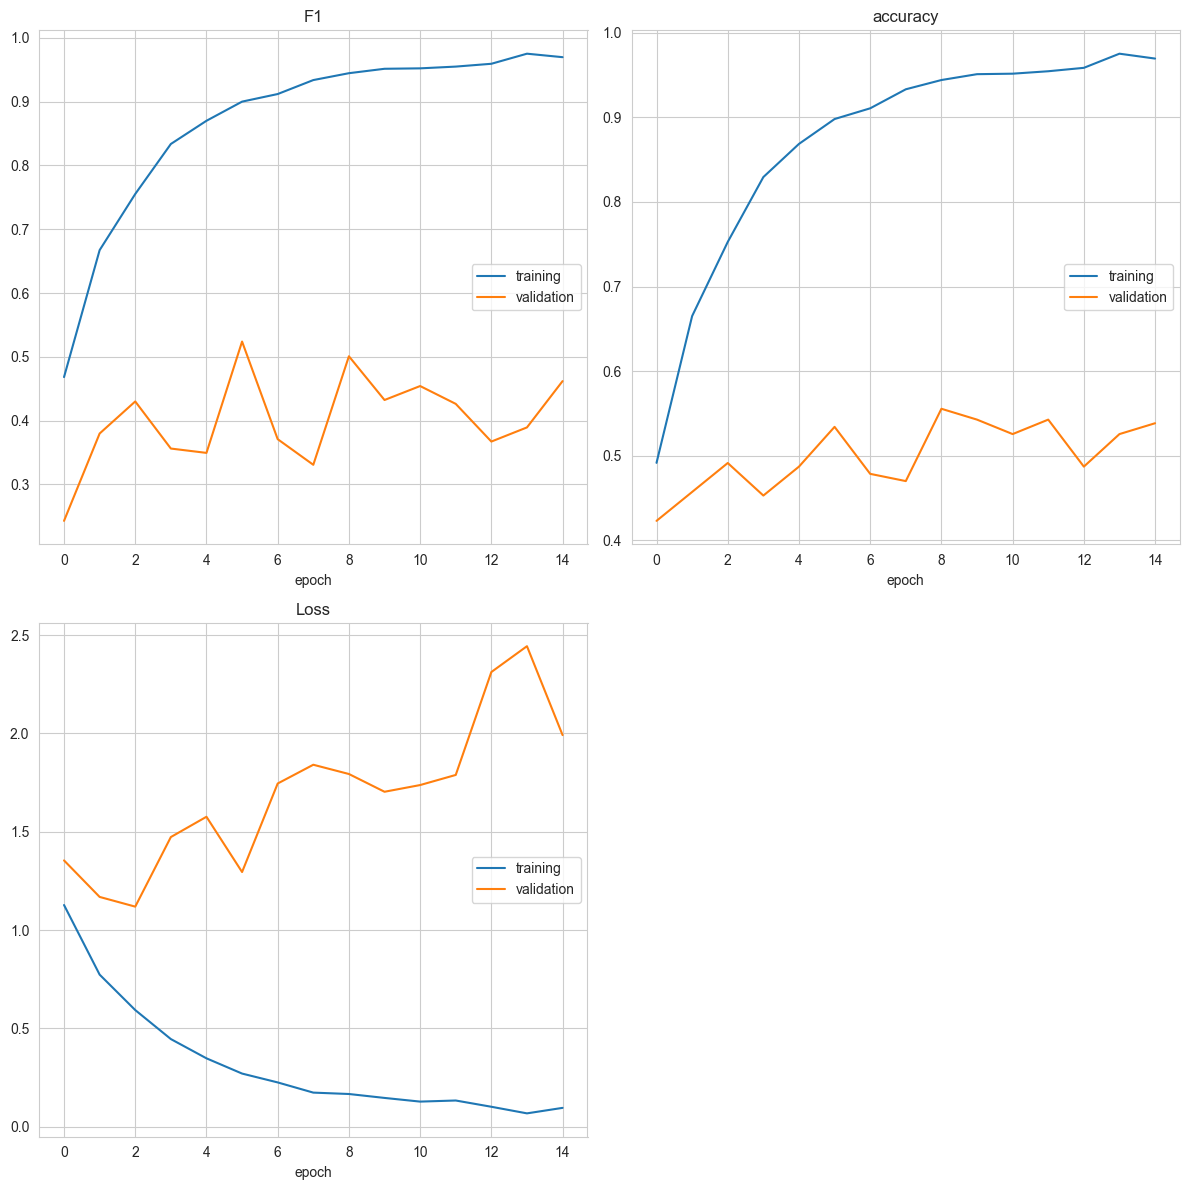

Early stopping at epoch 16
Best Val F1: 0.5239
Best Train F1: 0.9001
Best epoch: 6

train completed, best_metric: 0.5239 at epoch: 6
Time elapsed: 3073.6264449999726 seconds


In [10]:
from monai.losses import FocalLoss

EPOCHS = 60
LEARNING_RATE = 5e-5

loss_function = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.05)

starttime = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function, optimizer, EPOCHS, model_name)
endtime = time.perf_counter()

print(f"Time elapsed: {endtime - starttime} seconds")

## Avaliação


=========== TEST SET ===========
Accuracy TEST : 0.6592
F1 Macro TEST : 0.6426

               precision    recall  f1-score   support

Biliary_Leaks     0.4815    0.7647    0.5909        17
    Lithiasis     0.7931    0.5610    0.6571       123
       Normal     0.4730    0.8140    0.5983        43
    Stricture     0.7468    0.7024    0.7239        84

     accuracy                         0.6592       267
    macro avg     0.6236    0.7105    0.6426       267
 weighted avg     0.7071    0.6592    0.6645       267



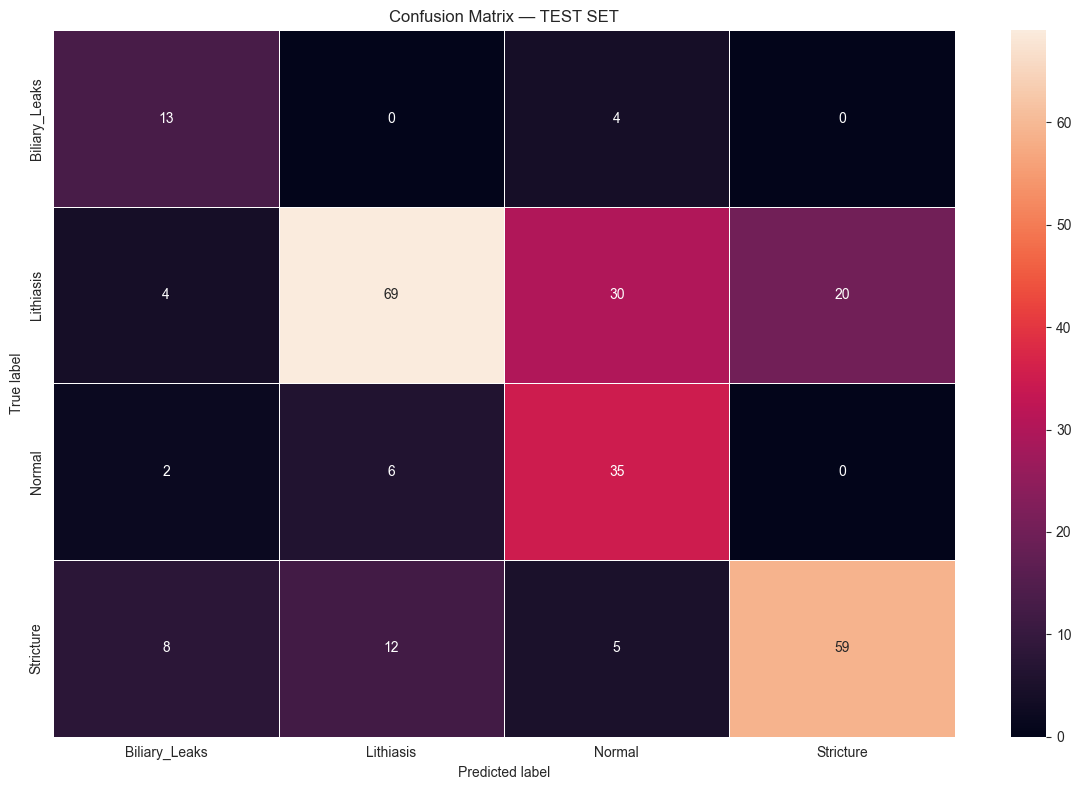

(0.6591760299625468, 0.6425672316776612)

In [ ]:
def evaluate_model(test_dl, model):
    predictions = []
    actual_values = []

    for inputs, labels in test_dl:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        outputs = outputs.detach().cpu().numpy()

        preds = np.argmax(outputs, axis=1)
        actual = labels.cpu().numpy()

        predictions.append(preds.reshape((len(preds), 1)))
        actual_values.append(actual.reshape((len(actual), 1)))

    predictions = np.vstack(predictions)
    actual_values = np.vstack(actual_values)

    acc = accuracy_score(actual_values, predictions)
    f1 = f1_score(actual_values, predictions, average="macro")

    print("\n=========== TEST SET ===========")
    print(f"Accuracy TEST : {acc:.4f}")
    print(f"F1 Macro TEST : {f1:.4f}\n")

    print(classification_report(actual_values, predictions, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(actual_values, predictions)

    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt="g",
                xticklabels=class_names, yticklabels=class_names,
                linewidths=.5)
    plt.title("Confusion Matrix — TEST SET")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

    return acc, f1


# carregar o modelo
model.load_state_dict(torch.load(model_name, map_location=device))
model.eval()

# avaliaar o modelo no test set
evaluate_model(test_loader, model)

## Grad Cam

In [1]:
!pip install -q grad-cam

Classes: ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
Test set: 267 imagens
Modelo carregado


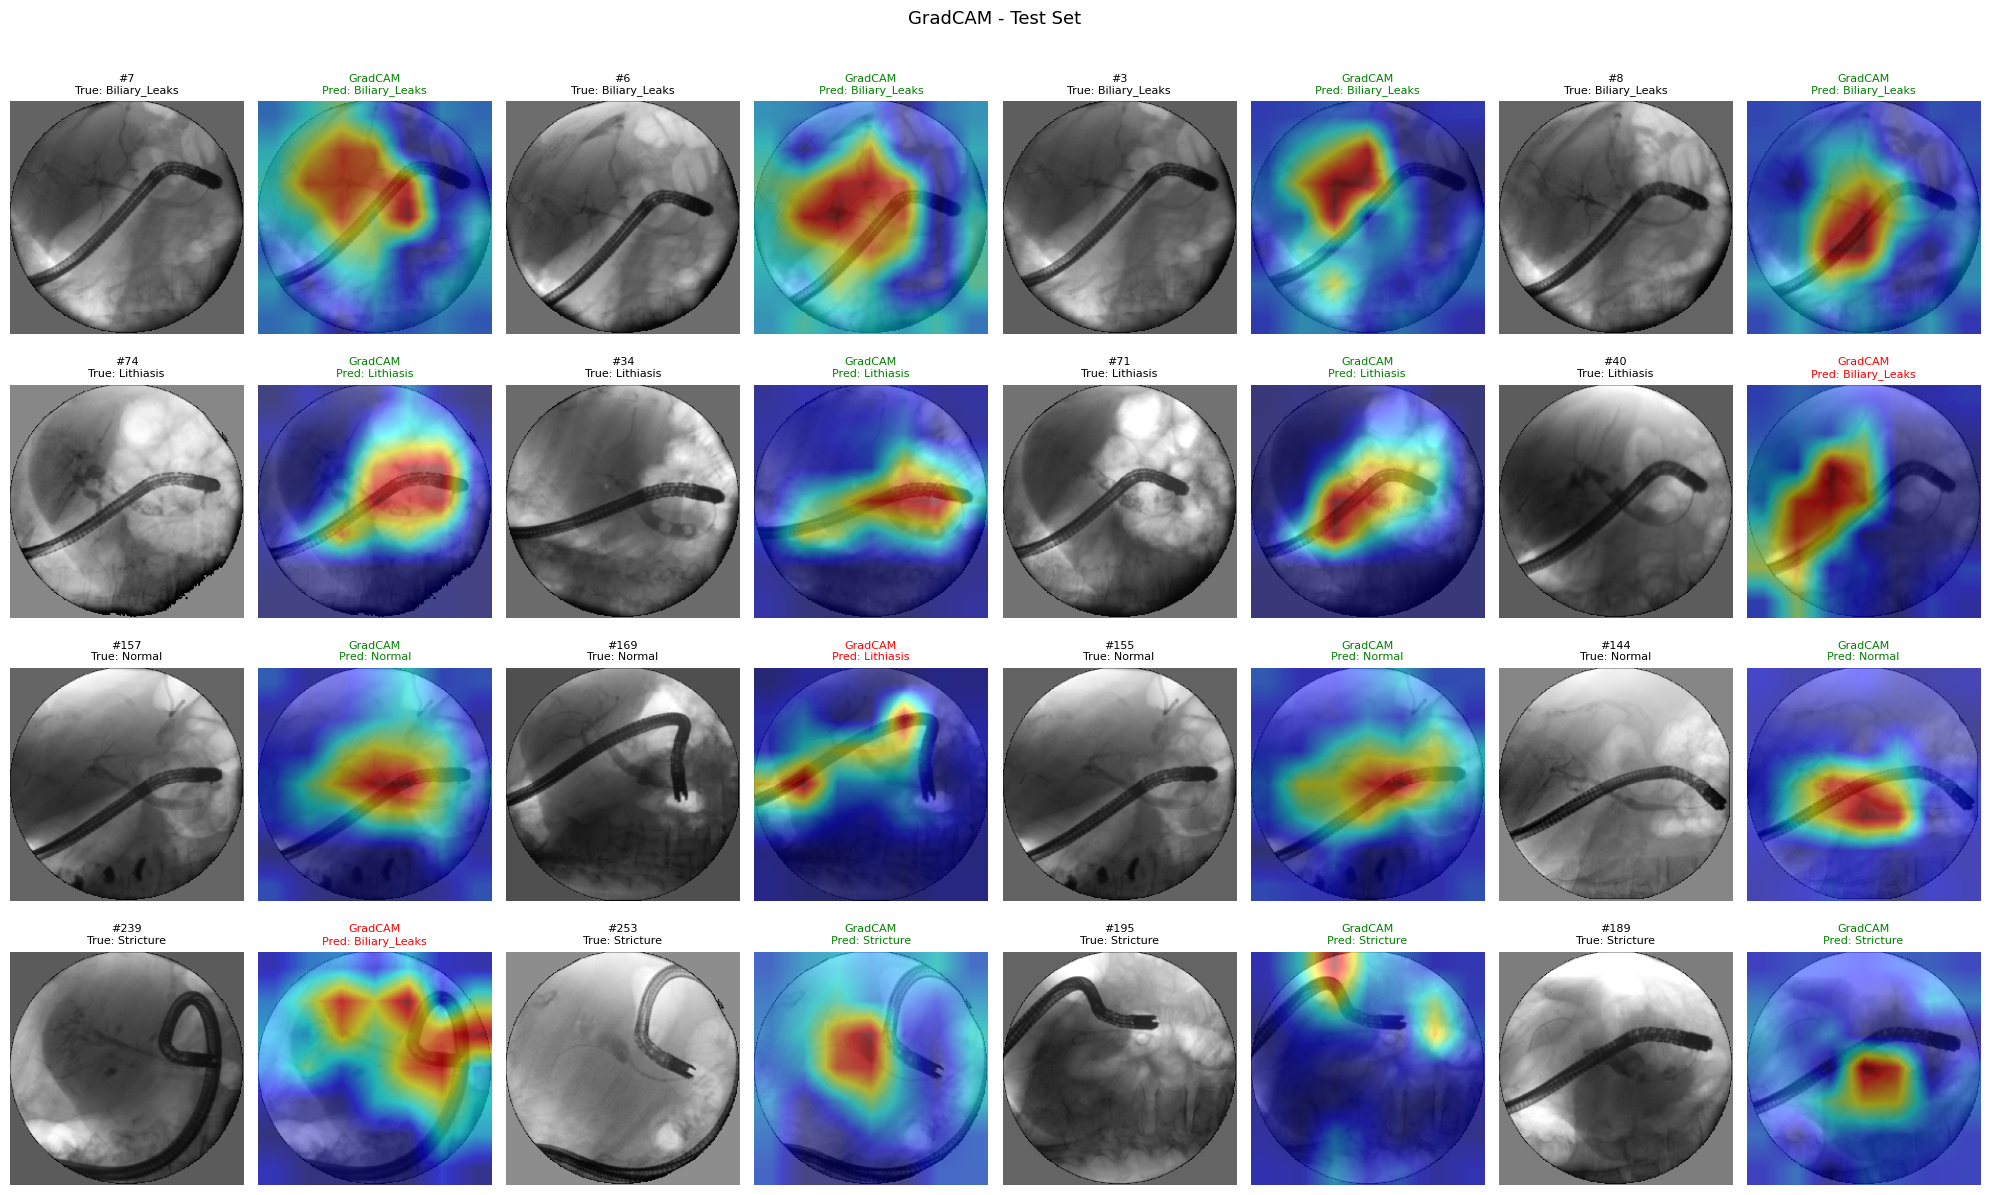

Guardado em gradcam_results.png


In [ ]:
# GRAD-CAM 
# carrega o pth guardado

import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
import torch
import timm
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from monai.transforms import (
    LoadImage, EnsureChannelFirst, Resize,
    ScaleIntensity, NormalizeIntensity, Lambda, ToTensor, Compose
)
from torch.utils.data import Dataset
import os


# Configurações
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_path = "./models/swin_tiny_IMG_GERADAS_Todas_cross_entropy.pth"
base_dir = "./dataset_monica"


# Classes
class_names = sorted([
    x for x in os.listdir(os.path.join(base_dir, "train"))
    if os.path.isdir(os.path.join(base_dir, "train", x))
])
num_class = len(class_names)
print("Classes:", class_names)


# Test dataset
valid_exts = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

test_images, test_labels = [], []
for i, class_name in enumerate(class_names):
    class_dir = os.path.join(base_dir, "test", class_name)
    files = [os.path.join(class_dir, f) for f in os.listdir(class_dir)
             if f.lower().endswith(valid_exts)]
    test_images.extend(files)
    test_labels.extend([i] * len(files))

print(f"Test set: {len(test_images)} imagens")

def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((224, 224)),
    ScaleIntensity(),
    Lambda(repeat_if_needed),
    NormalizeIntensity(nonzero=True, channel_wise=True),
    ToTensor()
])

class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms
    def __len__(self):
        return len(self.image_files)
    def __getitem__(self, index):
        return self.transforms(self.image_files[index]), self.labels[index]

test_ds = MedNISTDataset(test_images, test_labels, val_transforms)

# Carregar modelo com o pth guardado
model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=False,
    num_classes=num_class
)
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()
print("Modelo carregado")


# GradCAM
target_layers = [model.layers[-1].blocks[-1].norm1]

def reshape_transform_swin(tensor, height=None, width=None):
    # Calcula automaticamente as dimensões a partir do número de tokens
    n_tokens = tensor.shape[1]  
    if len(tensor.shape) == 4:
        result = tensor.permute(0, 3, 1, 2)
    else:
        import math
        h = w = int(math.sqrt(n_tokens))
        result = tensor.reshape(tensor.size(0), h, w, tensor.size(2))
        result = result.permute(0, 3, 1, 2)
    return result

def show_gradcam(dataset, indices, class_names, n_cols=4):
    n = len(indices)
    n_cols = min(n_cols, n)
    n_rows = (n + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols * 2,
                             figsize=(n_cols * 5, n_rows * 3))
    axes = np.array(axes).reshape(n_rows, n_cols * 2)

    with GradCAM(
        model=model,
        target_layers=target_layers,
        reshape_transform=reshape_transform_swin
    ) as cam:

        for plot_i, idx in enumerate(indices):
            img_tensor, true_label = dataset[idx]
            input_tensor = img_tensor.unsqueeze(0).to(device)

            with torch.no_grad():
                logits = model(input_tensor)
            pred_label = logits.argmax(dim=1).item()

            targets = [ClassifierOutputTarget(pred_label)]
            grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

            img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
            img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
            img_np = img_np.astype(np.float32)

            cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

            row = plot_i // n_cols
            col = (plot_i % n_cols) * 2

            axes[row, col].imshow(img_np)
            axes[row, col].set_title(f"#{idx}\nTrue: {class_names[true_label]}", fontsize=8)
            axes[row, col].axis("off")

            axes[row, col + 1].imshow(cam_image)
            axes[row, col + 1].set_title(
                f"GradCAM\nPred: {class_names[pred_label]}", fontsize=8,
                color="green" if pred_label == true_label else "red")
            axes[row, col + 1].axis("off")

    for ax in axes.flat:
        if not ax.images:
            ax.axis("off")

    plt.suptitle("GradCAM - Test Set", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("gradcam_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Guardado em gradcam_results.png")

# 4 amostras aleatórias por classe

indices_to_show = []
for class_idx in range(num_class):
    class_indices = [i for i, lbl in enumerate(test_ds.labels) if lbl == class_idx]
    indices_to_show.extend(random.sample(class_indices, min(4, len(class_indices))))

show_gradcam(test_ds, indices_to_show, class_names, n_cols=4)